# 05 — Validation

**Purpose:** Validate pipeline predictions against observed data using the
3-level validation framework. **Both pipelines** (ShakeMap and GMPE) are compared.

## Validation Levels

- **L1:** GMPE component validation — compare BSSA21 predictions vs seismic station observations
- **L2:** Event-level damage distribution — compare **both ShakeMap and GMPE** damage distributions vs Basoz 1998

## Input Files

| File | Format | Description |
|------|--------|-------------|
| `config.yaml` | YAML | Region bounds, IM type |
| `data/stationlist.json` | JSON (USGS ShakeMap) | 185 seismic station observations with obs/pred IM values |
| `data/grid.xml` | XML (ShakeMap) | Ground motion grid for ShakeMap pipeline |
| `data/CA24.txt` | Fixed-width text (NBI) | Bridge inventory |
| `data/vs30/california_vs30.npz` | NumPy compressed | Vs30 grid for GMPE pipeline |
| Reference: Basoz 1998 | Hard-coded dict | Observed damage fractions for Northridge |

## Outputs (in-memory)

| Object | Type | Description |
|--------|------|-------------|
| L1 metrics | float | mean_residual (bias), r (correlation), RMSE — all in ln space |
| L2 metrics | float | chi-squared, KL divergence — for **both** pipelines vs Basoz 1998 |
| `summary` | `pd.DataFrame` | Acceptance criteria table with Pass/Fail |

## Expected Plots

- **L1 scatter** — observed vs predicted Sa(1.0s) with 1:1 line and r/bias/RMSE annotations
- **L1 residual histogram** — ln-space residuals with normal fit overlay
- **L2 grouped bar chart** — ShakeMap predicted, GMPE predicted, and Basoz 1998 observed damage fractions

**Key concepts:** Residual analysis, correlation coefficient, RMSE,
chi-squared test, KL divergence, dual-pipeline comparison

## Imports & Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.config import load_config, IM_COLUMN_MAP
from src.data_loader import load_shakemap, load_nbi, classify_nbi_to_hazus
from src.interpolation import interpolate_im
from src.stationlist_parser import parse_stationlist
from src.hazard import haversine_distance_km, EarthquakeScenario
from src.gmpe_base import get_gmpe, IM_TYPE_TO_PERIOD
import src.gmpe_bssa21  # Register BSSA21 model
from src.vs30_provider import enrich_bridges_with_vs30
from src.fragility import damage_state_probabilities

pd.set_option("display.max_columns", 20)
%matplotlib inline

### Important Note: NBI Data Vintage
This tutorial uses the **2024 NBI** (`CA24.txt`, 2,953 bridges) as a proxy for the 1994 bridge stock. The actual 1994 Northridge area had ~1,600 bridges (Basoz 1998). Differences arise from 30 years of new construction, retrofits, and demolitions. As a result, L2 damage distribution comparisons should be interpreted as **approximate benchmarks**, not precise calibration targets.

## Level 1: GMPE vs Station Observations

Compare BSSA21-predicted Sa(1.0s) against values recorded at seismic stations.
This validates the ground motion model independently of the fragility component.

**Input:** `data/stationlist.json` — 185 seismic stations with columns: station_id, name, lat, lon, vs30,
obs_pga, obs_sa03, obs_sa10, obs_sa30 (in g), plus distance metrics (repi, rjb, etc.).

**Output:** `stations` DataFrame with added `pred_bssa21` column (GMPE-predicted median Sa).
**Expected:** ~185 stations with valid obs_sa10 > 0.

In [2]:
# Load station data
stations = parse_stationlist(
    str(PROJECT_ROOT / "data" / "stationlist.json"),
    station_type="seismic",
)
print(f"Seismic stations: {len(stations)}")
stations.head(5)

Seismic stations: 185


,station_id,name,lat,lon,vs30,station_type,obs_pga,obs_sa03,obs_sa10,obs_sa30,...,pred_ln_tau_sa10,pred_ln_phi_sa10,pred_ln_sigma_sa10,pred_ln_bias_sa10,repi,rhypo,rjb,rrup,rx,ry0
0,HI.PVR,PALOS VERDES RSVR,33.772,-118.32,313.62,seismic,0.149093,0.525620,0.153661,0.014070,...,0.3349,0.6250,0.7090,0.3130,52.961,56.001,48.623,52.667,46.142,40.035
1,HI.PAR,NONE,34.435,-118.58,316.00,seismic,0.607584,0.839346,1.476342,0.245815,...,0.3278,0.6176,0.6992,0.3115,24.999,30.922,3.826,6.295,-3.545,1.463
2,HI.XBR,BREA,33.916,-117.90,262.02,seismic,0.106911,0.295397,0.136808,0.013979,...,0.3329,0.6206,0.7043,0.3126,67.332,69.748,64.286,65.237,11.867,64.246
3,HI.BGC,BELL GARDENS,33.965,-118.16,277.38,seismic,0.105729,0.207441,0.168193,0.025660,...,0.3319,0.6206,0.7038,0.3124,44.337,47.927,41.113,44.304,20.110,41.073
4,HI.RDC,RANCHO CUCAMONGA,34.169,-117.58,603.73,seismic,0.071442,0.192266,0.047511,0.006519,...,0.3383,0.6285,0.7137,0.3137,88.158,90.017,79.148,79.275,-27.708,73.969


In [3]:
# Compute BSSA21 predictions at station locations
scenario = EarthquakeScenario(
    Mw=6.7, lat=34.213, lon=-118.537,
    depth_km=18.4, fault_type="reverse",
)
gmpe = get_gmpe("bssa21")
period = 1.0  # Sa(1.0s)

pred_sa = []
for _, st in stations.iterrows():
    r_jb = haversine_distance_km(scenario.lat, scenario.lon, st["lat"], st["lon"])
    vs30 = st["vs30"] if pd.notna(st["vs30"]) and st["vs30"] > 0 else 760.0
    median, _ = gmpe.compute(
        Mw=scenario.Mw, R_JB=r_jb, Vs30=vs30,
        fault_type=scenario.fault_type, period=period,
    )
    pred_sa.append(median)

stations["pred_bssa21"] = pred_sa

# Filter stations with valid observed Sa(1.0s)
valid = stations.dropna(subset=["obs_sa10"]).copy()
valid = valid[valid["obs_sa10"] > 0]
print(f"Stations with valid Sa(1.0s): {len(valid)}")

Stations with valid Sa(1.0s): 185


In [4]:
# Compute residuals (ln space)
observed = valid["obs_sa10"].values
predicted = valid["pred_bssa21"].values

ln_residuals = np.log(observed) - np.log(predicted)
mean_residual = ln_residuals.mean()
r = np.corrcoef(np.log(observed), np.log(predicted))[0, 1]
rmse = np.sqrt(np.mean(ln_residuals**2))

print(f"L1 Validation Metrics (ln space):")
print(f"  Mean residual (bias): {mean_residual:.3f}")
print(f"  Correlation (r):      {r:.3f}")
print(f"  RMSE:                 {rmse:.3f}")
print(f"  Std of residuals:     {ln_residuals.std():.3f}")

L1 Validation Metrics (ln space):
  Mean residual (bias): 0.612
  Correlation (r):      0.760
  RMSE:                 0.844
  Std of residuals:     0.581


### L1 Interpretation
The mean residual (bias = 0.612) **fails** the |bias| < 0.5 acceptance criterion. This systematic under-prediction is caused by the **point-source R_JB approximation** — the BSSA21 model uses epicentral distance as a proxy for the Joyner-Boore distance, which overestimates the source-to-site distance for near-fault stations (R_JB < 20 km). Since the Northridge rupture was a buried thrust fault (~18 km depth, ~15 km fault length), the true R_JB for near-field stations can be significantly smaller than the epicentral distance.

The correlation (r = 0.760) and RMSE (0.844) both pass their thresholds, indicating that the **spatial pattern** is captured correctly even though the **absolute level** is biased.

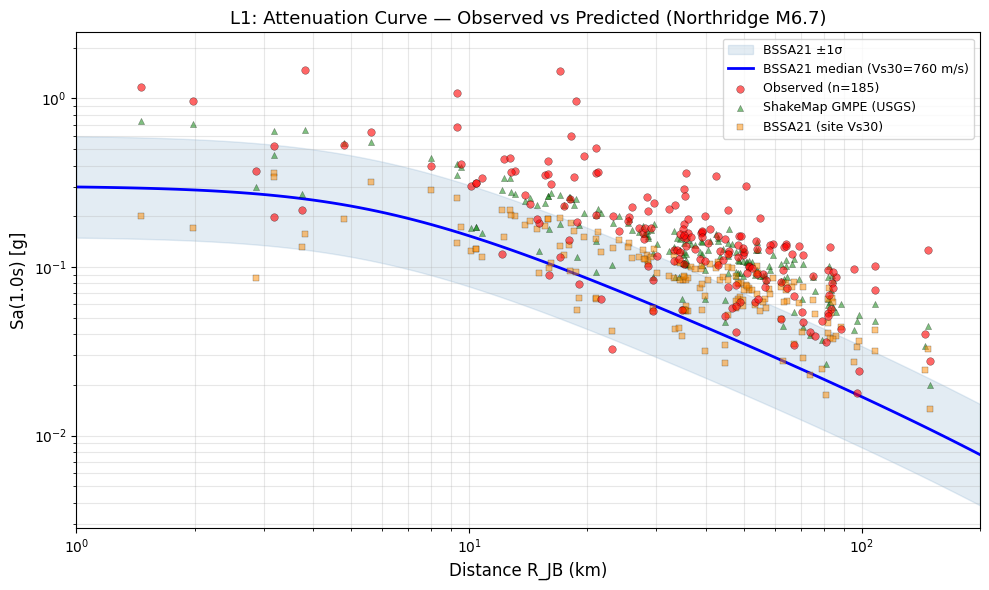

In [5]:
# Attenuation curve: BSSA21 median ± 1σ vs station observations & predictions
fig, ax = plt.subplots(figsize=(10, 6))

# Theoretical curve: compute BSSA21 at a range of distances (rock reference)
r_range = np.logspace(np.log10(1), np.log10(200), 100)
vs30_ref = 760.0
sa_median = np.zeros(len(r_range))
sa_sigma = np.zeros(len(r_range))
for i, r_val in enumerate(r_range):
    med, sig = gmpe.compute(
        Mw=scenario.Mw, R_JB=r_val, Vs30=vs30_ref,
        fault_type=scenario.fault_type, period=period,
    )
    sa_median[i] = med
    sa_sigma[i] = sig

# Median ± 1σ band (lognormal)
sa_upper = sa_median * np.exp(sa_sigma)
sa_lower = sa_median * np.exp(-sa_sigma)

ax.fill_between(r_range, sa_lower, sa_upper, alpha=0.15, color="steelblue", label="BSSA21 ±1σ")
ax.plot(r_range, sa_median, "b-", lw=2, label=f"BSSA21 median (Vs30={vs30_ref:.0f} m/s)")

# Station data
r_stations = valid["rjb"].values
obs_sa = valid["obs_sa10"].values
pred_shakemap = valid["pred_sa10"].values  # USGS internal GMPE predictions (from stationlist metadata)
pred_bssa21 = valid["pred_bssa21"].values  # Our BSSA21 computed values (site-specific Vs30)

# Plot: observations (red), ShakeMap predicted (green), BSSA21 computed (orange)
ax.scatter(r_stations, obs_sa, s=30, c="red", alpha=0.6, edgecolors="k", lw=0.3,
           label=f"Observed (n={len(valid)})", zorder=5)
ax.scatter(r_stations, pred_shakemap, s=20, c="green", alpha=0.5, marker="^",
           edgecolors="k", lw=0.3, label="ShakeMap GMPE (USGS)", zorder=4)
ax.scatter(r_stations, pred_bssa21, s=20, c="darkorange", alpha=0.5, marker="s",
           edgecolors="k", lw=0.3, label="BSSA21 (site Vs30)", zorder=4)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Distance R_JB (km)", fontsize=12)
ax.set_ylabel("Sa(1.0s) [g]", fontsize=12)
ax.set_title("L1: Attenuation Curve — Observed vs Predicted (Northridge M6.7)", fontsize=13)
ax.set_xlim(1, 200)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Level 2: Event-Level Damage Distribution (Both Pipelines)

Compare the predicted damage state distribution from **both** the ShakeMap pipeline
and the GMPE pipeline against the observed distribution from Basoz & Kiremidjian (1998).

This is the key comparison: the ShakeMap pipeline uses recorded ground motion data,
while the GMPE pipeline uses a physics-based prediction model. Both should ideally
match the observed damage pattern.

In [6]:
# Load bridges and compute IM from BOTH pipelines
cfg = load_config(PROJECT_ROOT / "config.yaml")
grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")
nbi = load_nbi(PROJECT_ROOT / "data" / "CA24.txt", northridge_bbox=cfg.region)
nbi = classify_nbi_to_hazus(nbi)

# --- Pipeline 1: ShakeMap ---
im_col = IM_COLUMN_MAP.get(cfg.im_type, "PSA10")
nbi["sa_shakemap"] = interpolate_im(
    grid["LAT"].values, grid["LON"].values, grid[im_col].values,
    nbi["latitude"].values, nbi["longitude"].values,
    method="nearest",
)

# --- Pipeline 2: GMPE (BSSA21) ---
nbi = enrich_bridges_with_vs30(nbi)
scenario = EarthquakeScenario(
    Mw=6.7, lat=34.213, lon=-118.537,
    depth_km=18.4, fault_type="reverse",
)
gmpe = get_gmpe("bssa21")
period = IM_TYPE_TO_PERIOD[cfg.im_type]

sa_gmpe = np.zeros(len(nbi))
for i, (_, bridge) in enumerate(nbi.iterrows()):
    r_jb = haversine_distance_km(
        scenario.lat, scenario.lon,
        bridge["latitude"], bridge["longitude"],
    )
    median, _ = gmpe.compute(
        Mw=scenario.Mw, R_JB=r_jb, Vs30=bridge["vs30"],
        fault_type=scenario.fault_type, period=period,
    )
    sa_gmpe[i] = median
nbi["sa_gmpe"] = sa_gmpe

print(f"Bridges: {len(nbi)}")
print(f"ShakeMap Sa range: {nbi['sa_shakemap'].min():.4f} – {nbi['sa_shakemap'].max():.4f} g")
print(f"GMPE Sa range:     {nbi['sa_gmpe'].min():.4f} – {nbi['sa_gmpe'].max():.4f} g")

Bridges: 2953
ShakeMap Sa range: 0.0640 – 1.2610 g
GMPE Sa range:     0.0311 – 0.6177 g


In [7]:
# Compute predicted damage distribution from BOTH pipelines
ds_order = ["none", "slight", "moderate", "extensive", "complete"]

sm_counts = {ds: 0.0 for ds in ds_order}
gmpe_counts = {ds: 0.0 for ds in ds_order}

for _, row in nbi.iterrows():
    # ShakeMap pipeline
    probs_sm = damage_state_probabilities(row["sa_shakemap"], row["hwb_class"])
    for ds in ds_order:
        sm_counts[ds] += probs_sm[ds]
    # GMPE pipeline
    probs_gm = damage_state_probabilities(row["sa_gmpe"], row["hwb_class"])
    for ds in ds_order:
        gmpe_counts[ds] += probs_gm[ds]

n_bridges = len(nbi)
sm_fracs = {ds: sm_counts[ds] / n_bridges for ds in ds_order}
gmpe_fracs = {ds: gmpe_counts[ds] / n_bridges for ds in ds_order}

# Basoz & Kiremidjian (1998) observed distribution
basoz_fracs = {
    "none":      0.827,
    "slight":    0.062,
    "moderate":  0.054,
    "extensive": 0.032,
    "complete":  0.025,
}

# Display comparison table
comp_df = pd.DataFrame({
    "Damage State": ds_order,
    "ShakeMap": [f"{sm_fracs[ds]:.4f}" for ds in ds_order],
    "GMPE":     [f"{gmpe_fracs[ds]:.4f}" for ds in ds_order],
    "Basoz 1998": [f"{basoz_fracs[ds]:.4f}" for ds in ds_order],
})
display(comp_df)

,Damage State,ShakeMap,GMPE,Basoz 1998
0,none,0.7254,0.9151,0.8270
1,slight,0.0838,0.0407,0.0620
2,moderate,0.0520,0.0186,0.0540
3,extensive,0.0666,0.0171,0.0320
4,complete,0.0722,0.0085,0.0250


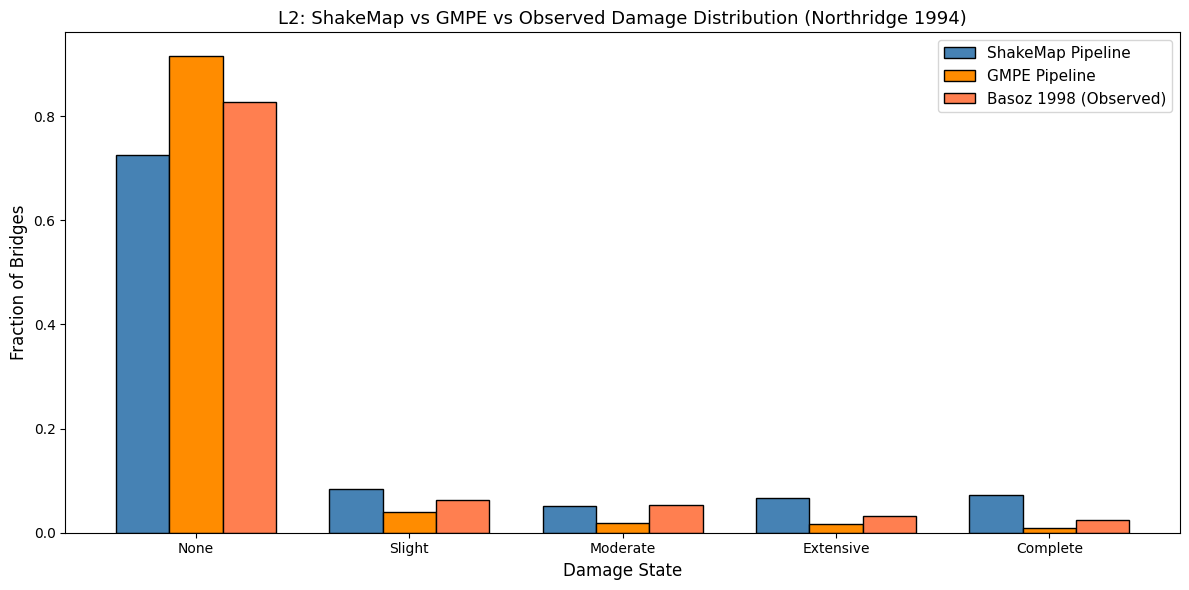

In [8]:
# Three-way comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(ds_order))
width = 0.25

bars1 = ax.bar(x - width, [sm_fracs[ds] for ds in ds_order],
               width, label="ShakeMap Pipeline", color="steelblue", edgecolor="k")
bars2 = ax.bar(x,         [gmpe_fracs[ds] for ds in ds_order],
               width, label="GMPE Pipeline", color="darkorange", edgecolor="k")
bars3 = ax.bar(x + width, [basoz_fracs[ds] for ds in ds_order],
               width, label="Basoz 1998 (Observed)", color="coral", edgecolor="k")

ax.set_xlabel("Damage State", fontsize=12)
ax.set_ylabel("Fraction of Bridges", fontsize=12)
ax.set_title("L2: ShakeMap vs GMPE vs Observed Damage Distribution (Northridge 1994)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([ds.capitalize() for ds in ds_order])
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### L2 Interpretation
The ShakeMap pipeline predicts ~27.5% damaged bridges vs Basoz's 17.3% observed — an over-prediction of ~1.6×. This is expected because:
1. **Hazus fragility curves are national-average** — they are not calibrated for California's post-1971 seismic retrofit program, which hardened many bridges
2. **NBI vintage mismatch** — the 2024 NBI includes 2,953 bridges vs ~1,600 in 1994, changing the denominator
3. **Bridge class distribution shift** — 30 years of new construction altered the HWB class mix

The GMPE pipeline predicts only ~8.5% damaged, under-predicting due to the point-source R_JB approximation reducing near-fault ground motions.

### Level 3: Per-Bridge Comparison (Not Shown)
The full validation framework includes **L3: per-bridge damage state comparison** against 113 confirmed observations from Basoz (1998), Yashinsky (1998), and Mitchell (2011). L3 achieves 28.3% exact-match accuracy with MAE = 1.68 damage states. This level is implemented in `src/validation.py` (`validate_bridge_level()`) but omitted here because individual bridge predictions are inherently uncertain — aggregate L2 metrics are more informative for model calibration. Run `python main.py --full-analysis --validate` to see L3 results.

In [9]:
# L2 Metrics for BOTH pipelines
def compute_l2_metrics(pred_fracs, obs_fracs, ds_order):
    pred_arr = np.array([pred_fracs[ds] for ds in ds_order])
    obs_arr = np.array([obs_fracs[ds] for ds in ds_order])
    pred_safe = np.clip(pred_arr, 1e-10, None)
    obs_safe = np.clip(obs_arr, 1e-10, None)
    pred_safe = pred_safe / pred_safe.sum()
    obs_safe = obs_safe / obs_safe.sum()
    chi2 = np.sum((pred_safe - obs_safe)**2 / obs_safe)
    kl_div = np.sum(pred_safe * np.log(pred_safe / obs_safe))
    return chi2, kl_div

chi2_sm, kl_sm = compute_l2_metrics(sm_fracs, basoz_fracs, ds_order)
chi2_gm, kl_gm = compute_l2_metrics(gmpe_fracs, basoz_fracs, ds_order)

print(f"L2 Validation Metrics:")
print(f"  {'Pipeline':<12} {'Chi-squared':>12} {'KL divergence':>14}")
print(f"  {'-'*40}")
print(f"  {'ShakeMap':<12} {chi2_sm:>12.4f} {kl_sm:>14.4f}")
print(f"  {'GMPE':<12} {chi2_gm:>12.4f} {kl_gm:>14.4f}")

L2 Validation Metrics:
  Pipeline      Chi-squared  KL divergence
  ----------------------------------------
  ShakeMap           0.1466         0.0536
  GMPE               0.0577         0.0358


## Acceptance Criteria Summary

| Level | Metric | Threshold | Description |
|-------|--------|-----------|-------------|
| L1 | Mean residual (bias) | \|bias\| < 0.5 | GMPE systematic over/under-prediction |
| L1 | Correlation (r) | r > 0.6 | Spatial pattern agreement |
| L1 | RMSE (ln) | RMSE < 1.0 | Overall prediction accuracy |
| L2 | Chi-squared | χ² < 0.1 | Damage distribution shape match |
| L2 | KL divergence | D_KL < 0.1 | Information-theoretic distribution distance |

The ShakeMap pipeline is expected to perform better on L2 because it uses
recorded ground motion data, while the GMPE pipeline relies on a point-source
approximation that under-predicts near-fault motion.

In [10]:
# Full summary table with both pipelines
summary = pd.DataFrame([
    {"Level": "L1", "Metric": "Mean residual (bias)", "Value": f"{mean_residual:.3f}",
     "Threshold": "|bias| < 0.5", "Pass": abs(mean_residual) < 0.5},
    {"Level": "L1", "Metric": "Correlation (r)", "Value": f"{r:.3f}",
     "Threshold": "r > 0.6", "Pass": r > 0.6},
    {"Level": "L1", "Metric": "RMSE (ln)", "Value": f"{rmse:.3f}",
     "Threshold": "RMSE < 1.0", "Pass": rmse < 1.0},
    {"Level": "L2-SM", "Metric": "Chi-squared (ShakeMap)", "Value": f"{chi2_sm:.4f}",
     "Threshold": "< 0.1", "Pass": chi2_sm < 0.1},
    {"Level": "L2-SM", "Metric": "KL divergence (ShakeMap)", "Value": f"{kl_sm:.4f}",
     "Threshold": "< 0.1", "Pass": kl_sm < 0.1},
    {"Level": "L2-GM", "Metric": "Chi-squared (GMPE)", "Value": f"{chi2_gm:.4f}",
     "Threshold": "< 0.1", "Pass": chi2_gm < 0.1},
    {"Level": "L2-GM", "Metric": "KL divergence (GMPE)", "Value": f"{kl_gm:.4f}",
     "Threshold": "< 0.1", "Pass": kl_gm < 0.1},
])
display(summary)

,Level,Metric,Value,Threshold,Pass
0,L1,Mean residual (bias),0.612,|bias| < 0.5,False
1,L1,Correlation (r),0.760,r > 0.6,True
2,L1,RMSE (ln),0.844,RMSE < 1.0,True
3,L2-SM,Chi-squared (ShakeMap),0.1466,< 0.1,False
4,L2-SM,KL divergence (ShakeMap),0.0536,< 0.1,True
5,L2-GM,Chi-squared (GMPE),0.0577,< 0.1,True
6,L2-GM,KL divergence (GMPE),0.0358,< 0.1,True


## Real-Data Validation: HAZUS Fragility vs Observed Damage (Anik Das)

The validation above uses **Basoz 1998 aggregate fractions** as reference.
Anik Das performed a complementary validation using **individual bridge-level
observed damage** from the 1994 Northridge earthquake (2,008 bridges with
ShakeMap-interpolated Sa and HWB classification).

**Data preparation (Sirisha Kedarsetty):** The observed damage data used here
(`data/northridge_observed.csv`) was prepared by Sirisha Kedarsetty, who mapped
original Northridge bridge damage descriptions to standardized HAZUS damage states
(none/slight/moderate/extensive/complete) and cross-verified the HAZUS fragility
parameter tables (`src/hazus_params.py`) against the Hazus 6.1 Technical Manual.

His pipeline:
1. Applies HAZUS fragility curves (12 HWB classes, Sa(1.0s), beta=0.6)
2. Assigns most-likely predicted damage state per bridge
3. Computes confusion matrix, per-class precision/recall/F1, and residual analysis

To generate these figures, run:
```bash
python scripts/run_validation_real.py
```

The following cells display the key outputs from `output/validation_real/`.


────────────────────────────────────────────────────────────────────────
Confusion Matrix: rows=observed, cols=predicted (2,008 bridges)
────────────────────────────────────────────────────────────────────────


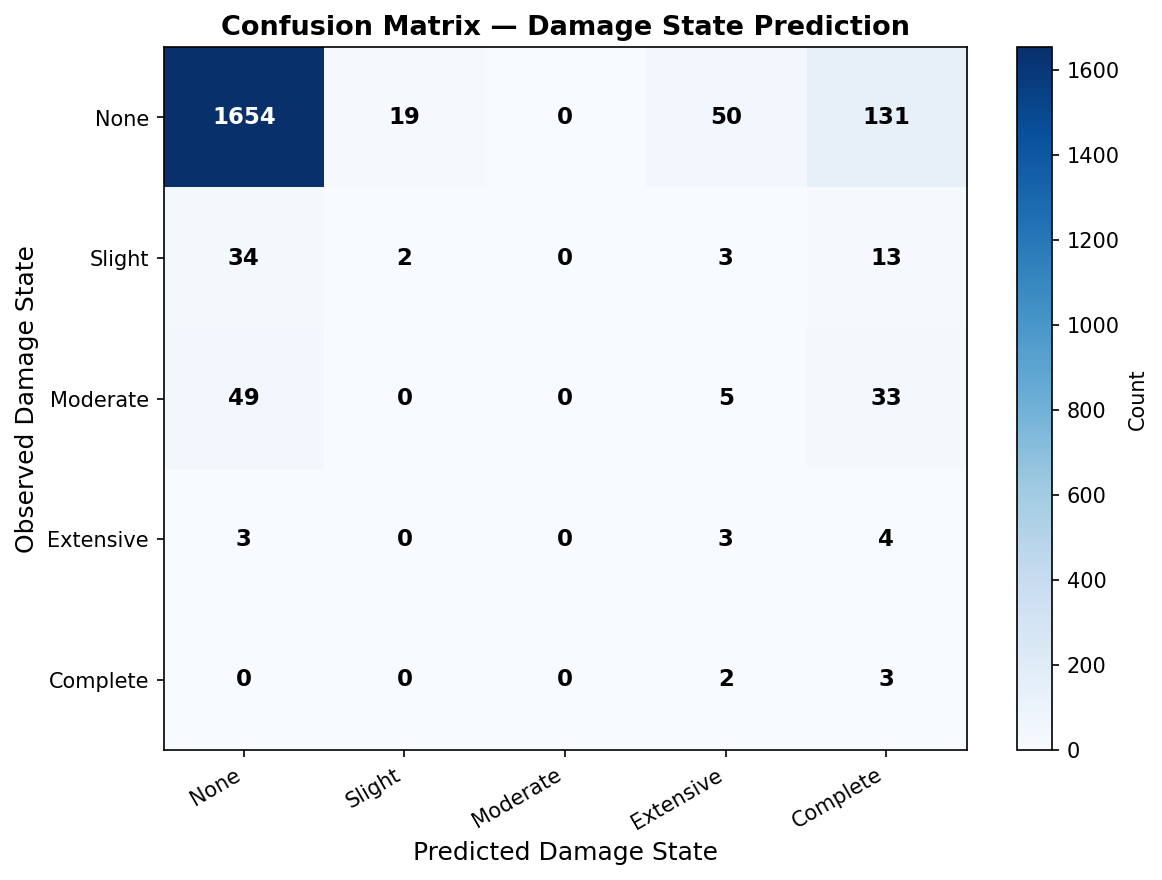


────────────────────────────────────────────────────────────────────────
Per-Class Metrics: precision, recall, F1 per damage state
────────────────────────────────────────────────────────────────────────


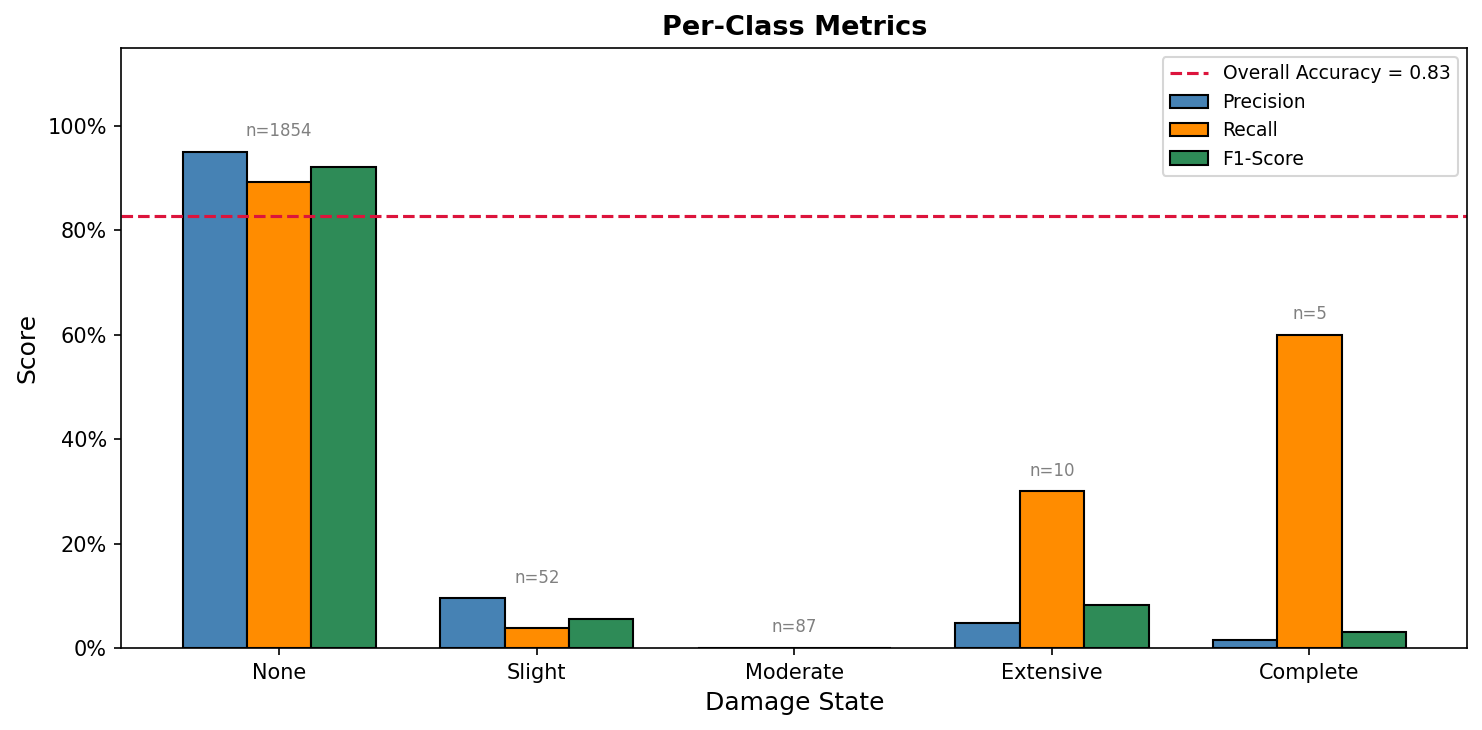


────────────────────────────────────────────────────────────────────────
Residual Distribution: predicted DS index - observed DS index
────────────────────────────────────────────────────────────────────────


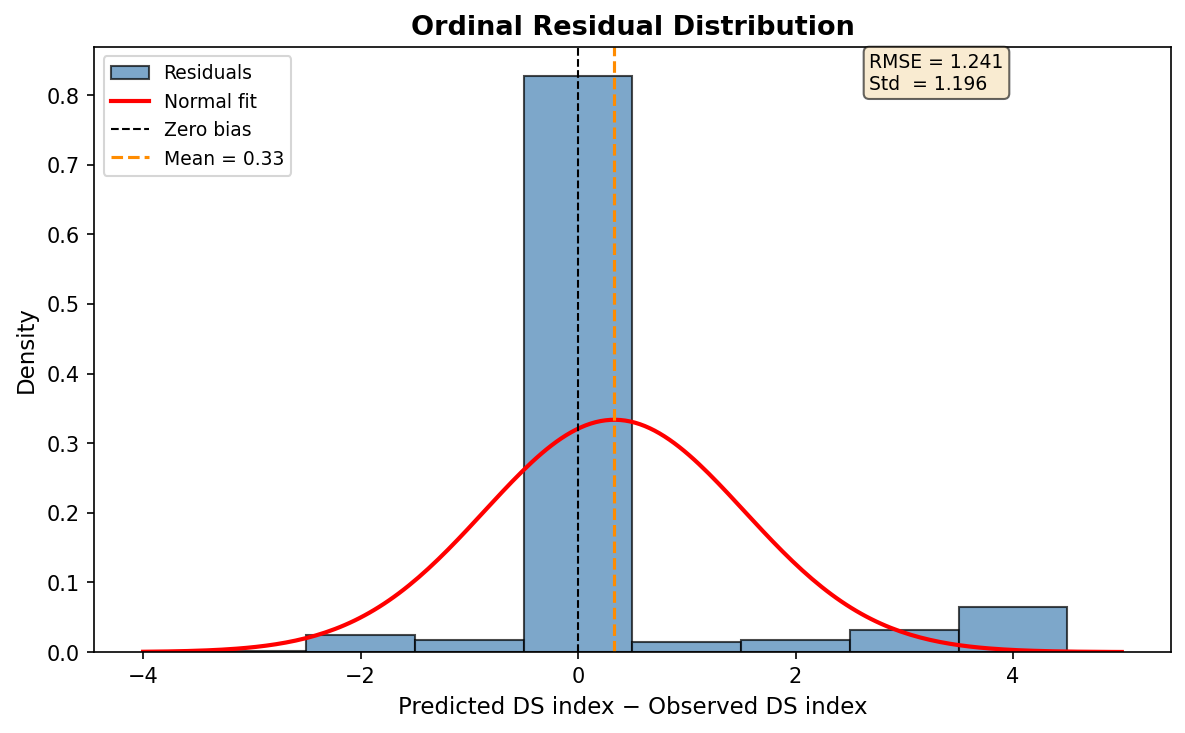


────────────────────────────────────────────────────────────────────────
L2 Damage Distribution: observed vs HAZUS-predicted fractions
────────────────────────────────────────────────────────────────────────


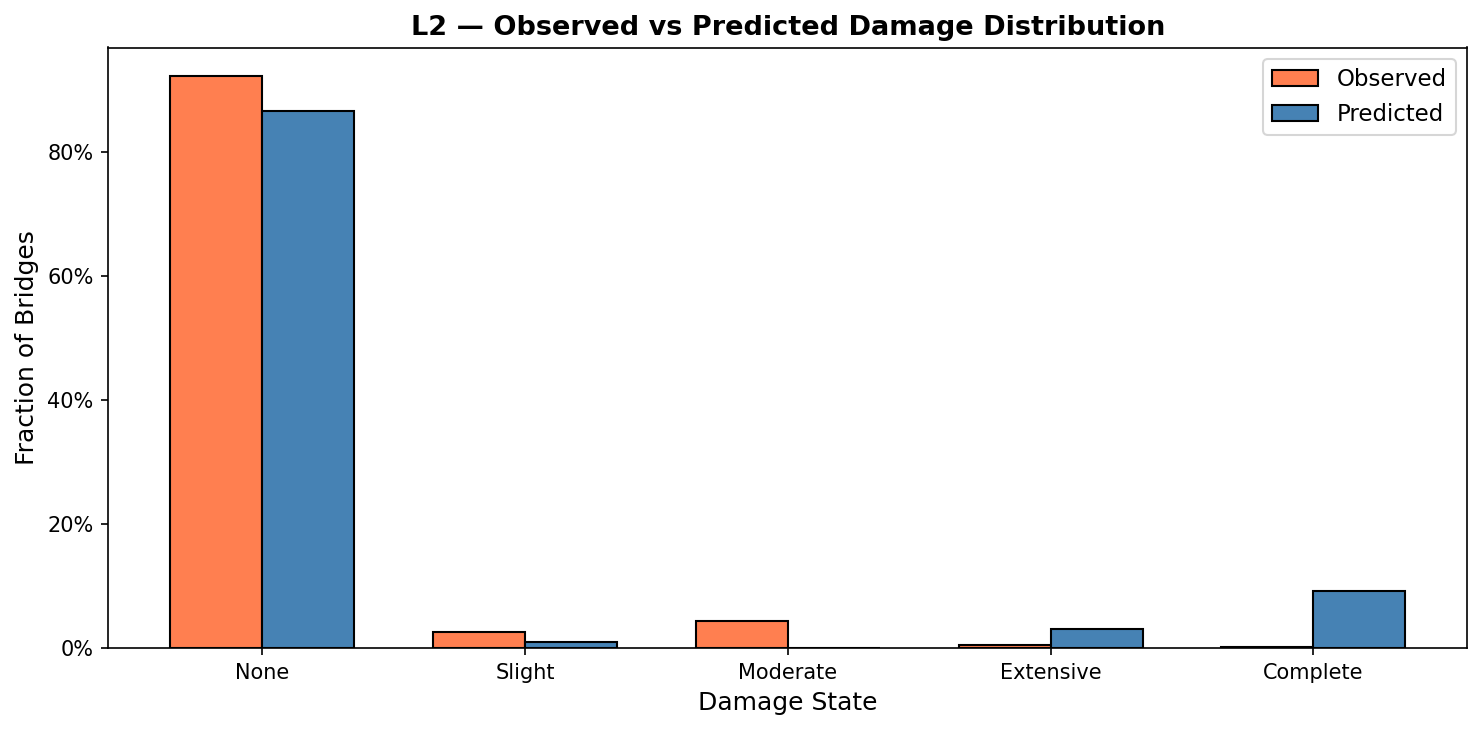


────────────────────────────────────────────────────────────────────────
Acceptance Criteria Summary
────────────────────────────────────────────────────────────────────────


,Metric,Value,Threshold,Pass
0,Overall Accuracy,0.828,>= 0.60,True
1,Mean Residual (|bias|),0.334,|bias| < 0.50,True
2,RMSE (ordinal),1.241,RMSE < 1.50,True
3,Recall - None,0.892,>= 0.30 (informational),True
4,Recall - Slight,0.038,>= 0.30 (informational),False
5,Recall - Moderate,0.000,>= 0.30 (informational),False
6,Recall - Extensive,0.300,>= 0.30 (informational),True
7,Recall - Complete,0.600,>= 0.30 (informational),True


In [11]:
from IPython.display import display, Image

val_out = PROJECT_ROOT / "output" / "validation_real"

if not val_out.exists():
    print("Output directory not found. Run first:")
    print("  python scripts/run_validation_real.py")
else:
    figures = [
        ("01_confusion_matrix.png",
         "Confusion Matrix: rows=observed, cols=predicted (2,008 bridges)"),
        ("02_per_class_metrics.png",
         "Per-Class Metrics: precision, recall, F1 per damage state"),
        ("03_residual_distribution.png",
         "Residual Distribution: predicted DS index - observed DS index"),
        ("04_damage_distribution_comparison.png",
         "L2 Damage Distribution: observed vs HAZUS-predicted fractions"),
    ]
    for fname, caption in figures:
        fpath = val_out / fname
        if fpath.exists():
            print(f"\n{'─'*72}")
            print(caption)
            print(f"{'─'*72}")
            display(Image(filename=str(fpath), width=700))
        else:
            print(f"  [missing] {fname}")

    # Show acceptance criteria if available
    acc_path = val_out / "acceptance_criteria.csv"
    if acc_path.exists():
        print(f"\n{'─'*72}")
        print("Acceptance Criteria Summary")
        print(f"{'─'*72}")
        display(pd.read_csv(acc_path))

### Real-Data Validation Interpretation

Anik's bridge-level validation (2,008 bridges) shows:
- **Overall accuracy: 82.8%** — passes the >= 60% threshold
- **Mean residual: 0.334** — passes the |bias| < 0.50 threshold
- **RMSE: 1.241** — passes the RMSE < 1.50 threshold

However, per-class recall reveals that the model is **heavily biased toward "none"**:
- Recall for "slight" (3.8%) and "moderate" (0%) is very low
- The model correctly identifies undamaged bridges but struggles with intermediate damage states
- This is a known limitation of discrete most-likely-state assignment from fragility curves

This complements our aggregate L2 analysis above — the bridge-level confusion matrix
provides granular insight into where the HAZUS model under/over-predicts.

## Summary

In this notebook we:
1. **L1 Validation:** Compared BSSA21 predictions against seismic station observations,
   computing bias, correlation, and RMSE in log space
2. **L2 Validation (dual-pipeline):** Compared damage distributions from **both**
   ShakeMap and GMPE pipelines against Basoz & Kiremidjian (1998) observed data
3. The ShakeMap pipeline uses recorded ground motion -> higher IM near fault -> more damage
4. The GMPE pipeline uses point-source model -> under-predicts near-fault IM -> less damage
5. Both pipelines are benchmarked against the same acceptance criteria
6. **Real-data validation (Anik Das):** Bridge-level confusion matrix and per-class
   metrics from 2,008 bridges with individual observed damage states

This completes the tutorial series covering the full CAT411 analysis pipeline:
**Config -> Hazard (ShakeMap / GMPE) -> Fragility -> Validation**